In [1]:
# Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df.job_posted_date)

In [3]:
# 1. Create df_jobs
jobs_data = {
    'job_id': [1, 2, 3, 4, 5],
    'job_title': [
        'Data Scientist', 
        'Software Engineer', 
        'Product Manager', 
        'Marketing Director', 
        'HR Manager'
    ],
    'company_name': ['Google', 'Microsoft', 'Apple', 'Nike', 'Starbucks'],
    'job_location': [
        'Mountain View, CA', 
        'Redmond, WA', 
        'Cupertino, CA', 
        'Beaverton, OR', 
        'Seattle, WA'
    ]
}

df_jobs = pd.DataFrame(jobs_data)

# 2. Create df_companies
companies_data = {
    'company_name': ['Google', 'Microsoft', 'Apple', 'Nike', 'Starbucks'],
    'industry': ['Technology', 'Technology', 'Technology', 'Apparel', 'Food & Beverage'],
    'company_size': ['100,000+', '100,000+', '100,000+', '75,000+', '346,000+']
}

df_companies = pd.DataFrame(companies_data)

# Display the DataFrames
print("df_jobs:")
print(df_jobs)
print("\ndf_companies:")
print(df_companies)

df_jobs:
   job_id           job_title company_name       job_location
0       1      Data Scientist       Google  Mountain View, CA
1       2   Software Engineer    Microsoft        Redmond, WA
2       3     Product Manager        Apple      Cupertino, CA
3       4  Marketing Director         Nike      Beaverton, OR
4       5          HR Manager    Starbucks        Seattle, WA

df_companies:
  company_name         industry company_size
0       Google       Technology     100,000+
1    Microsoft       Technology     100,000+
2        Apple       Technology     100,000+
3         Nike          Apparel      75,000+
4    Starbucks  Food & Beverage     346,000+


In [4]:
df_jobs

,job_id,job_title,company_name,job_location
0,1,Data Scientist,Google,"Mountain View, CA"
1,2,Software Engineer,Microsoft,"Redmond, WA"
2,3,Product Manager,Apple,"Cupertino, CA"
3,4,Marketing Director,Nike,"Beaverton, OR"
4,5,HR Manager,Starbucks,"Seattle, WA"


In [5]:
df_companies

,company_name,industry,company_size
0,Google,Technology,"100,000+"
1,Microsoft,Technology,"100,000+"
2,Apple,Technology,"100,000+"
3,Nike,Apparel,"75,000+"
4,Starbucks,Food & Beverage,"346,000+"


In [6]:
# To merge the above two dataframes, use the 'pd.DataFrames.merge()' method

df_jobs.merge(df_companies, on = 'company_name')

,job_id,job_title,company_name,job_location,industry,company_size
0,1,Data Scientist,Google,"Mountain View, CA",Technology,"100,000+"
1,2,Software Engineer,Microsoft,"Redmond, WA",Technology,"100,000+"
2,3,Product Manager,Apple,"Cupertino, CA",Technology,"100,000+"
3,4,Marketing Director,Nike,"Beaverton, OR",Apparel,"75,000+"
4,5,HR Manager,Starbucks,"Seattle, WA",Food & Beverage,"346,000+"


In [8]:
df_usa = df[df['job_country'] == 'United States'].copy()
df_usa['job_posted_month'] = df_usa['job_posted_date'].dt.strftime('%B')
df_usa_pivot = df_usa.pivot_table(index = 'job_posted_month', columns = 'job_title_short', aggfunc = ['size'])
df_usa_pivot.reset_index(inplace = True)
df_usa_pivot['month_no'] = pd.to_datetime(df_usa_pivot['job_posted_month'], format = '%B').dt.month
df_usa_pivot.sort_values(by = 'month_no', inplace = True)
df_usa_pivot.set_index('job_posted_month')
df_usa_pivot.drop(columns = 'month_no', inplace = True)
df_usa_pivot.set_index('job_posted_month', inplace = True)
df_usa_pivot

C:\Users\Shivangi\AppData\Local\Temp\ipykernel_2988\91564653.py:8: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df_usa_pivot.drop(columns = 'month_no', inplace = True)


size  ...                  
job_title_short  Business Analyst  ... Software Engineer
job_posted_month                   ...                  
January                       527  ...               114
February                      447  ...                90
March                         438  ...               115
April                         565  ...               112
May                           279  ...                90
June                          446  ...                93
July                          581  ...               153
August                        903  ...               194
September                     897  ...               228
October                       932  ...               219
November                      719  ...               194
December                      648  ...               212

[12 rows x 10 columns]

In [11]:
pd.read_csv('https://lukeb.co/software_csv')

,job_posted_month,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
0,January,13619,9827,5108,4348
1,February,11456,9116,7298,4284
2,March,11102,8178,5814,4159
3,April,14037,9209,7232,4220
4,May,12126,8864,6718,4980
5,June,12003,8065,5902,4781
6,July,11914,8061,6839,4344
7,August,11571,8191,7413,4104
8,September,14016,8447,6139,4094
9,October,11419,8476,5026,4389


In [14]:
df_usa_software_pivot = pd.read_csv('https://lukeb.co/software_csv', index_col = 'job_posted_month')
df_usa_software_pivot

,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
job_posted_month,,,,
January,13619,9827,5108,4348
February,11456,9116,7298,4284
March,11102,8178,5814,4159
April,14037,9209,7232,4220
May,12126,8864,6718,4980
June,12003,8065,5902,4781
July,11914,8061,6839,4344
August,11571,8191,7413,4104
September,14016,8447,6139,4094


In [18]:
df_usa_merged = df_usa_pivot['size'].merge(df_usa_software_pivot, on = 'job_posted_month')
df_usa_merged

,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
job_posted_month,,,,,,,,,,,,,,
January,527,36,8494,2655,6915,60,1544,773,1552,114,13619,9827,5108,4348
February,447,24,6124,3060,4956,56,1258,878,1127,90,11456,9116,7298,4284
March,438,19,6218,3183,4779,59,1114,829,1150,115,11102,8178,5814,4159
April,565,40,6049,2801,4867,51,1025,781,991,112,14037,9209,7232,4220
May,279,20,4993,2976,4377,49,839,746,914,90,12126,8864,6718,4980
June,446,32,5683,2893,4645,48,1009,812,1033,93,12003,8065,5902,4781
July,581,39,5201,2570,4876,65,883,747,1095,153,11914,8061,6839,4344
August,903,39,6634,3269,6318,68,1186,903,1515,194,11571,8191,7413,4104
September,897,50,4639,3224,4568,113,805,775,1014,228,14016,8447,6139,4094


In [24]:
top_5 = (
    df_usa_merged
    .sum()
    .sort_values(ascending = False)
    .head()
    .index
    .tolist()
)
top_5

['Front-End Developer',
 'Back-End Developer',
 'Full-Stack Developer',
 'Data Analyst',
 'Data Scientist']

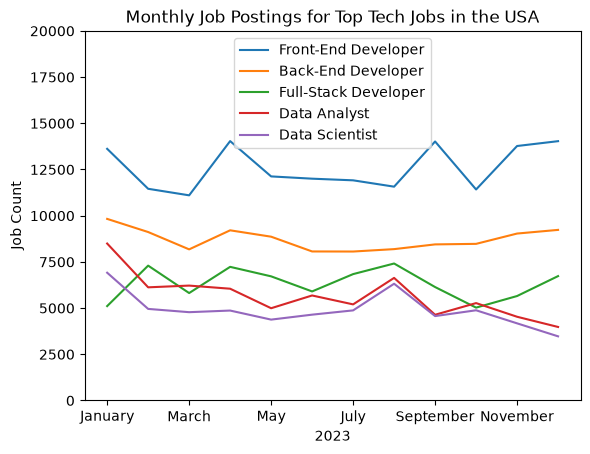

In [26]:
df_usa_merged[top_5].plot(kind = 'line')
plt.title('Monthly Job Postings for Top Tech Jobs in the USA')
plt.xlabel('2023')
plt.ylabel('Job Count')
plt.ylim(0, 20000)
plt.legend()
plt.show()